Dataset Preview:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


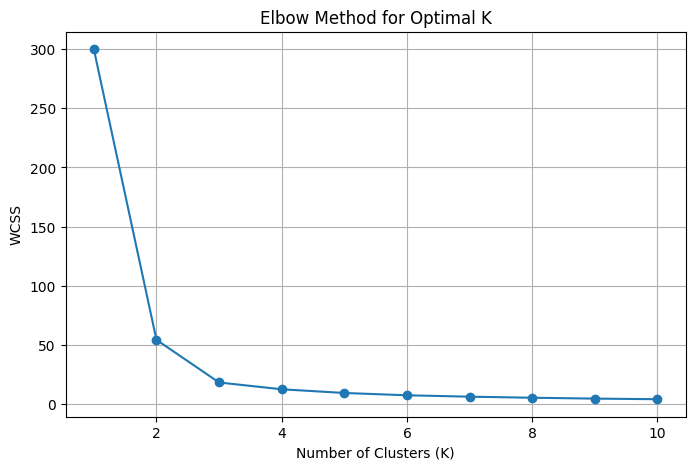


Clustered Data:
   sepal_length  sepal_width  petal_length  petal_width species  Cluster
0           5.1          3.5           1.4          0.2  setosa        1
1           4.9          3.0           1.4          0.2  setosa        1
2           4.7          3.2           1.3          0.2  setosa        1
3           4.6          3.1           1.5          0.2  setosa        1
4           5.0          3.6           1.4          0.2  setosa        1
5           5.4          3.9           1.7          0.4  setosa        1
6           4.6          3.4           1.4          0.3  setosa        1
7           5.0          3.4           1.5          0.2  setosa        1
8           4.4          2.9           1.4          0.2  setosa        1
9           4.9          3.1           1.5          0.1  setosa        1

Cluster Centers (scaled values):
[[ 1.02813193  1.12749028]
 [-1.30487835 -1.25512862]
 [ 0.30564587  0.16609419]]


In [1]:
# K-Means Clustering on iris.csv
# -----------------------------

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("iris.csv")

# Display first rows
print("Dataset Preview:")
print(df.head())

# ---------------------------------
# Select only Petal Length & Width
# ---------------------------------

# Change column names if needed
X = df[['petal_length', 'petal_width']]

# ---------------------------------
# Feature Scaling
# ---------------------------------
# Scaling helps because K-Means uses Euclidean distance

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---------------------------------
# Elbow Method
# ---------------------------------

wcss = []   # Within Cluster Sum of Squares

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

# Plot Elbow Graph
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

# ---------------------------------
# Build Final KMeans Model
# ---------------------------------
# From elbow plot choose K = 3

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
y_pred = kmeans.fit_predict(X_scaled)

# Add clusters to dataset
df['Cluster'] = y_pred

print("\nClustered Data:")
print(df.head(10))

# Cluster Centers
print("\nCluster Centers (scaled values):")
print(kmeans.cluster_centers_)